# Conductance-Based LIF Pipeline (Modular)

This notebook is the recommended orchestration path for the conductance-based clustered LIF workflow. It imports the shared `lif_simulation` package instead of embedding the full simulation, loading, analysis, and plotting pipeline inline.

The original `LIF_network_simulation_network_burst_conductance.ipynb` notebook is retained as the monolithic reference/extraction notebook, while plotting and reusable workflow logic live in the package modules and thin scripts.

**Suggested first-time run order:**
1. Run the import cell.
2. Review the configuration cell and keep `execute_main_simulation = False` on the first pass.
3. Run the no-stimulation validation cell and the sag/rebound probe cell.
4. Check the printed validation verdict plus the raster and voltage plots.
5. Set `execute_main_simulation = True` only when the quick validation outputs look reasonable.
6. After a session is saved, use `session_source` and `recording_index` in the later cells to load and inspect that recording.

**How to choose the run mode:**
- For spontaneous activity, keep `burst_interval` extremely large and set `cluster_fraction = 0.0` with `neurons_per_cluster = 0`.
- For stimulus-driven bursting, use a finite `burst_interval` together with nonzero cluster stimulation settings.
- Toggle `use_h_current` in the configuration cell when you want the h-current enabled or disabled for ablation.

**What this notebook writes:**
- Saved sessions under `LIF data/<timestamp>`
- Raw full-dt voltage traces by default, stored in chunked HDF5 sidecars during saved sessions
- Shared plotting outputs built from `lif_simulation/plotting.py`

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

from lif_simulation.analysis import analyze_spike_trains, compute_hub_firing_rate_groups, validate_hub_structure
from lif_simulation.plotting import (
    plot_combined_network_layout,
    plot_firing_rates,
    plot_hub_degree_distributions,
    plot_hub_firing_rate_histogram,
    plot_hub_network,
    plot_network_positions,
    plot_raster,
    plot_resampled_raster,
    plot_sag_probe,
    plot_spike_train_analysis_summary,
    plot_voltage_heatmap,
    plot_voltage_traces,
)
from lif_simulation.probes import run_h_current_step_probe, run_no_stimulation_validation, summarize_h_current_step_probe
from lif_simulation.session_views import load_session_bundle
from lif_simulation.workflows import sequential_simulation_individual_saves

In [7]:
seed = 41
np.random.seed(seed)
random.seed(seed)

validation_config = {
    'seed': seed,
    'use_h_current': True,
    'test_duration_ms': 12000,
    'requested_voltage_sample_rate': 0.25,
}

sag_probe_config = {
    'step_current_nA': -0.12,
    'duration_ms': 1200.0,
    'dt': 0.1,
}

execute_main_simulation = True
simulation_params = {
    'n_recordings': 20,
    'recording_duration': 60000,
    'num_clusters': 30,
    'neurons_per_cluster_range': (12, 18),
    'inhibitory_probability': 0.2,
    'within_cluster_prob': 0.3,
    'between_cluster_prob': 0.15,
    'target_freq': 10,
    'save_dir': 'LIF data',
    'dt': 0.1,
    'record_voltage': True,
    'voltage_sample_rate': 1.0,
    'voltage_storage_backend': 'hdf5_external',
    'voltage_chunk_samples': 4096,
    'space_size': 15,
    'max_connection_distance': 6.0,
    'use_h_current': True,
    'burst_interval': 12000,
    'cluster_fraction': 0.5,
    'neurons_per_cluster': 2,
    'stim_amplitude_range': (2.0, 3.5),
    'stim_duration_range': (10, 30),
    'burst_interval_jitter': 1500,
    'hub_fraction': 0.1,
    'hub_between_prob': 0.25,
    'hub_weight_scale': 1.5,
    'hub_reciprocal_factor': 2.0,
}

session_source = 'latest'
recording_index = 0

Created 297 neurons in 20 clusters
Created 1018 base synaptic connections
  Within-cluster: 925, Between-cluster: 93

Designated 20 hub neurons (6.7% of network)
Added 614 hub connections
Total connections: 1632 (base: 1018, hub: 614)

Simulating 120000 ms of network activity...
  Mode: Spontaneous activity (no external stimulation)
  External stimulation events: 0
  Built synapse lookup: 290 presynaptic neurons
  Voltage recording: raw membrane voltage at every dt step (0.1000 ms)
  Progress: 0%
  Progress: 10%
  Progress: 20%
  Progress: 30%
  Progress: 40%
  Progress: 50%
  Progress: 60%
  Progress: 70%
  Progress: 80%
  Progress: 90%
  Progress: 100%
Simulation complete!

NO_STIM_TEST
use_h_current=True
external_stimulation_events=0
test_duration_s=120.0
requested_voltage_sample_rate_ms=0.25
saved_voltage_step_ms=0.1
voltage_trace_mode=raw_full_dt
raster_window_s=60.0
n_neurons=297
total_spikes=6510
active_neurons=292
mean_rate_hz=0.18265993265993266
median_rate_hz=0.19166666666666

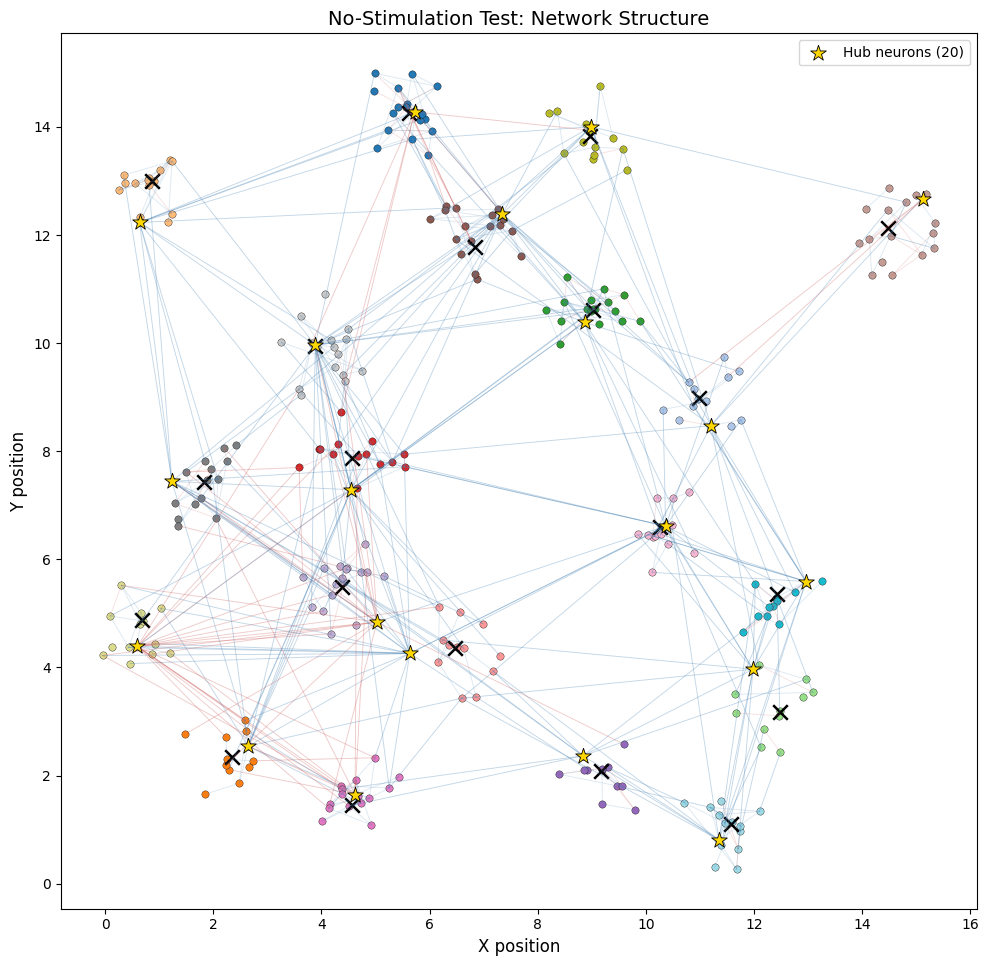

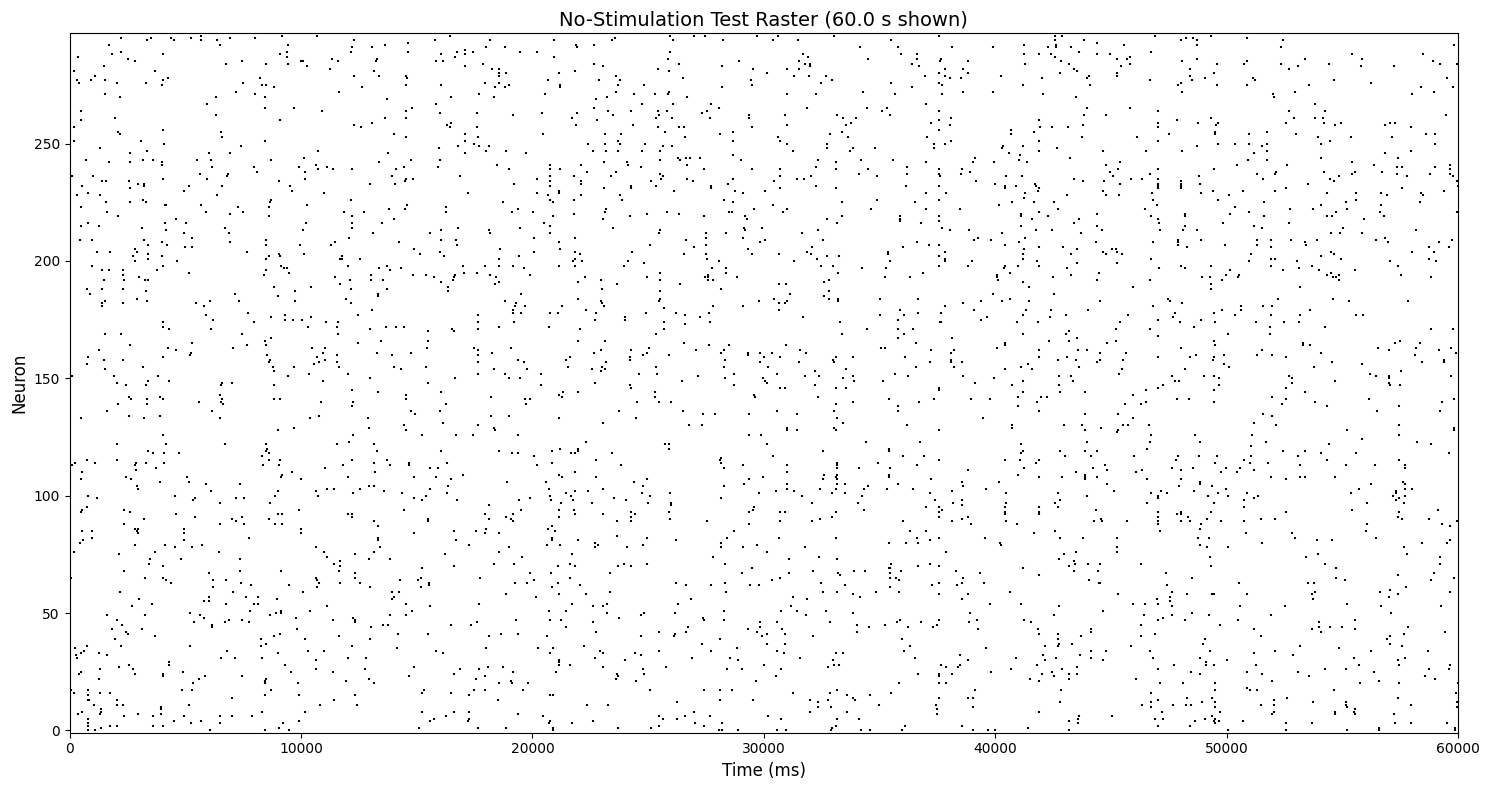

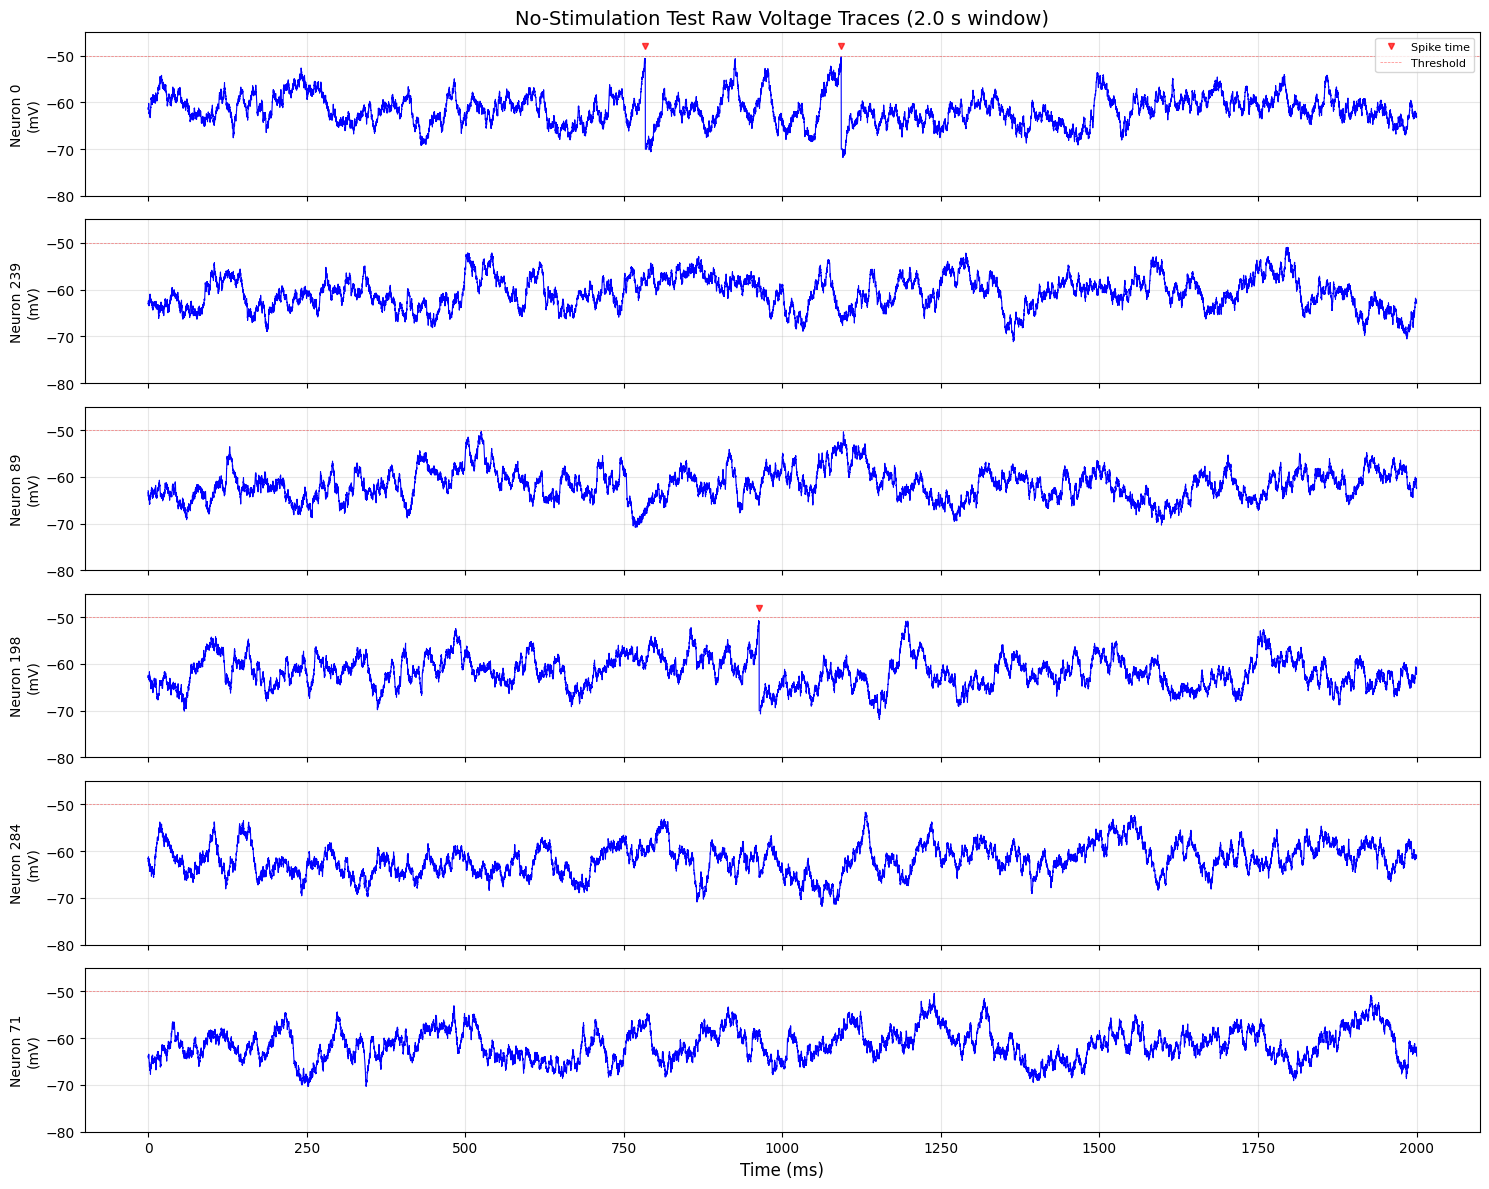

In [3]:
validation_result = run_no_stimulation_validation(**validation_config)
validation_metrics = validation_result['metrics']

print('NO_STIM_TEST')
for key in [
    'use_h_current',
    'external_stimulation_events',
    'test_duration_s',
    'requested_voltage_sample_rate_ms',
    'saved_voltage_step_ms',
    'voltage_trace_mode',
    'raster_window_s',
    'n_neurons',
    'total_spikes',
    'active_neurons',
    'mean_rate_hz',
    'median_rate_hz',
    'max_rate_hz',
    'max_active_fraction_100ms',
    'bins_ge_10pct',
    'bins_ge_25pct',
    'bins_ge_50pct',
    'verdict',
]:
    print(f'{key}={validation_metrics[key]}')

validation_raster_spike_data = {
    neuron_id: [spike for spike in spikes if spike <= validation_result['raster_window_ms']]
    for neuron_id, spikes in validation_result['spike_data'].items()
}

plot_combined_network_layout(
    validation_result['neuron_positions'],
    validation_result['cluster_info'],
    validation_result['connections'],
    cluster_assignments=validation_result['cluster_assignments'],
    max_connections=validation_result['max_connections_plot'],
    title='No-Stimulation Test: Network Structure',
)
plt.show()

plot_raster(
    validation_raster_spike_data,
    validation_result['cluster_assignments'],
    validation_result['raster_window_ms'],
    title=f"No-Stimulation Test Raster ({validation_result['raster_window_ms'] / 1000.0:.1f} s shown)",
)
plt.show()

plot_voltage_traces(
    validation_result['voltage_data'],
    neuron_ids=validation_result['example_neuron_ids'],
    time_range=(0, validation_result['voltage_window_ms']),
    spike_data=validation_result['spike_data'],
    title=f"No-Stimulation Test Raw Voltage Traces ({validation_result['voltage_window_ms'] / 1000.0:.1f} s window)",
)
plt.show()

H_CURRENT_SAG_TEST
step_current_nA=-0.120
sag_depth_with_h_mV=1.195
sag_depth_without_h_mV=-0.000
rebound_with_h_mV=1.258
rebound_without_h_mV=-0.007


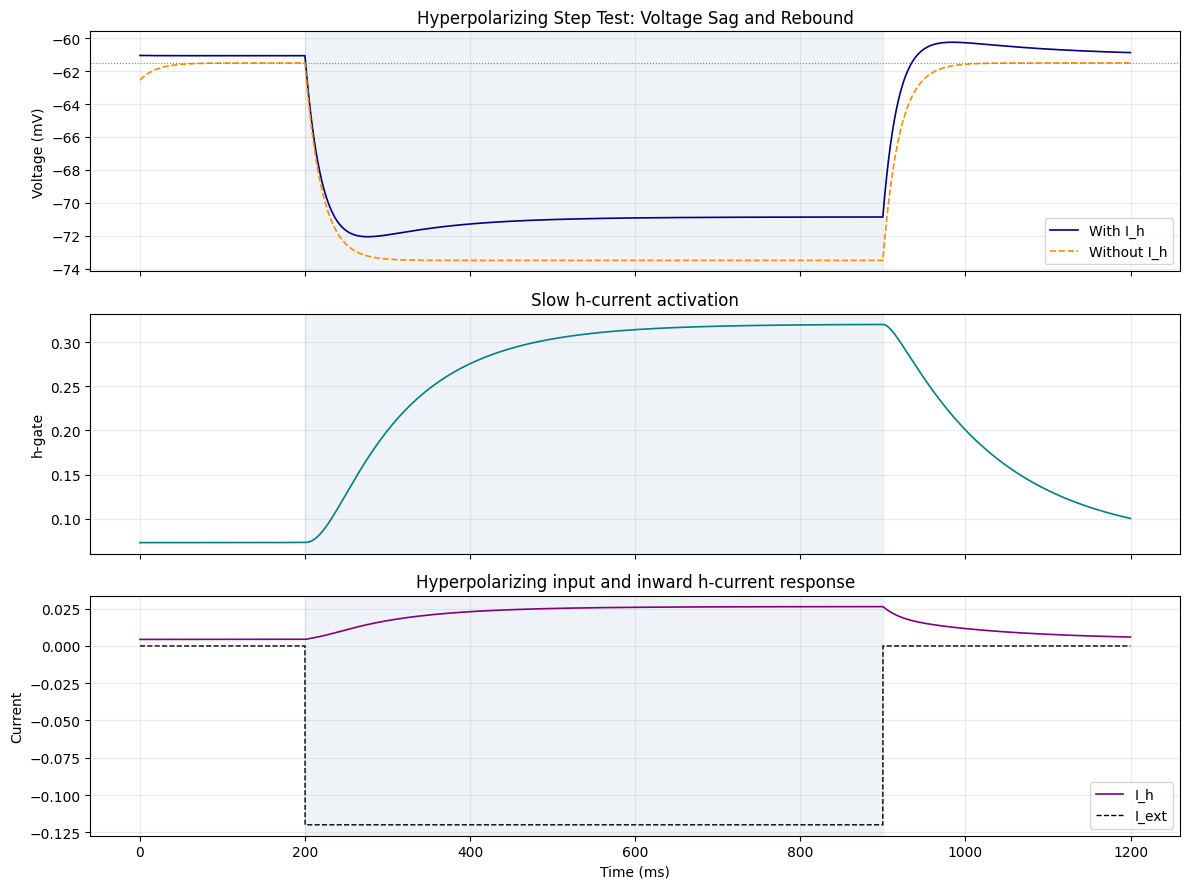

In [ ]:
sag_with_h = run_h_current_step_probe(use_h_current=True, **sag_probe_config)
sag_without_h = run_h_current_step_probe(use_h_current=False, **sag_probe_config)
sag_summary = summarize_h_current_step_probe(sag_with_h, sag_without_h)

print('H_CURRENT_SAG_TEST')
for key, value in sag_summary.items():
    print(f'{key}={value:.3f}' if isinstance(value, float) else f'{key}={value}')

plot_sag_probe(sag_with_h, sag_without_h)
plt.show()

In [8]:
if execute_main_simulation:
    np.random.seed(seed)
    random.seed(seed)
    session_metadata = sequential_simulation_individual_saves(**simulation_params)
    print(f"Saved session to: {session_metadata['session_dir']}")
else:
    print('Main simulation skipped. Set execute_main_simulation = True to run it.')


STARTING SEQUENTIAL SIMULATION SESSION: 20260521_130004
Mode: stimulus_driven_bursting
Synapse model: conductance-based with legacy weight scaling
H-current enabled: True
Number of recordings: 20
Recording duration: 60 seconds
Save directory: LIF data\20260521_130004
Record voltage: True
Saved voltage resolution: raw full-dt membrane voltage at 0.1000 ms
Voltage storage backend: chunked external HDF5 (4096 samples per flush)
Requested voltage_sample_rate=1.0000 ms is ignored for saved traces
Space size: 15
Max connection distance: 6.0
Target resampling frequency: 10 Hz
Burst interval: 12000 ms (0.08 Hz) +/- 1500 ms
Cluster fraction: 50%
Neurons per cluster: 2
Hub fraction: 10% | Hub between prob: 0.25
Hub weight scale: 1.5x | Hub reciprocal factor: 2.0x

Creating network...
Created 445 neurons in 30 clusters
Created 1656 base synaptic connections
  Within-cluster: 1450, Between-cluster: 206

Designated 30 hub neurons (6.7% of network)
Added 1068 hub connections
Total connections: 2724

Loading session: 20260521_130004
Session folder: LIF data\20260521_130004
Relative session path: 20260521_130004


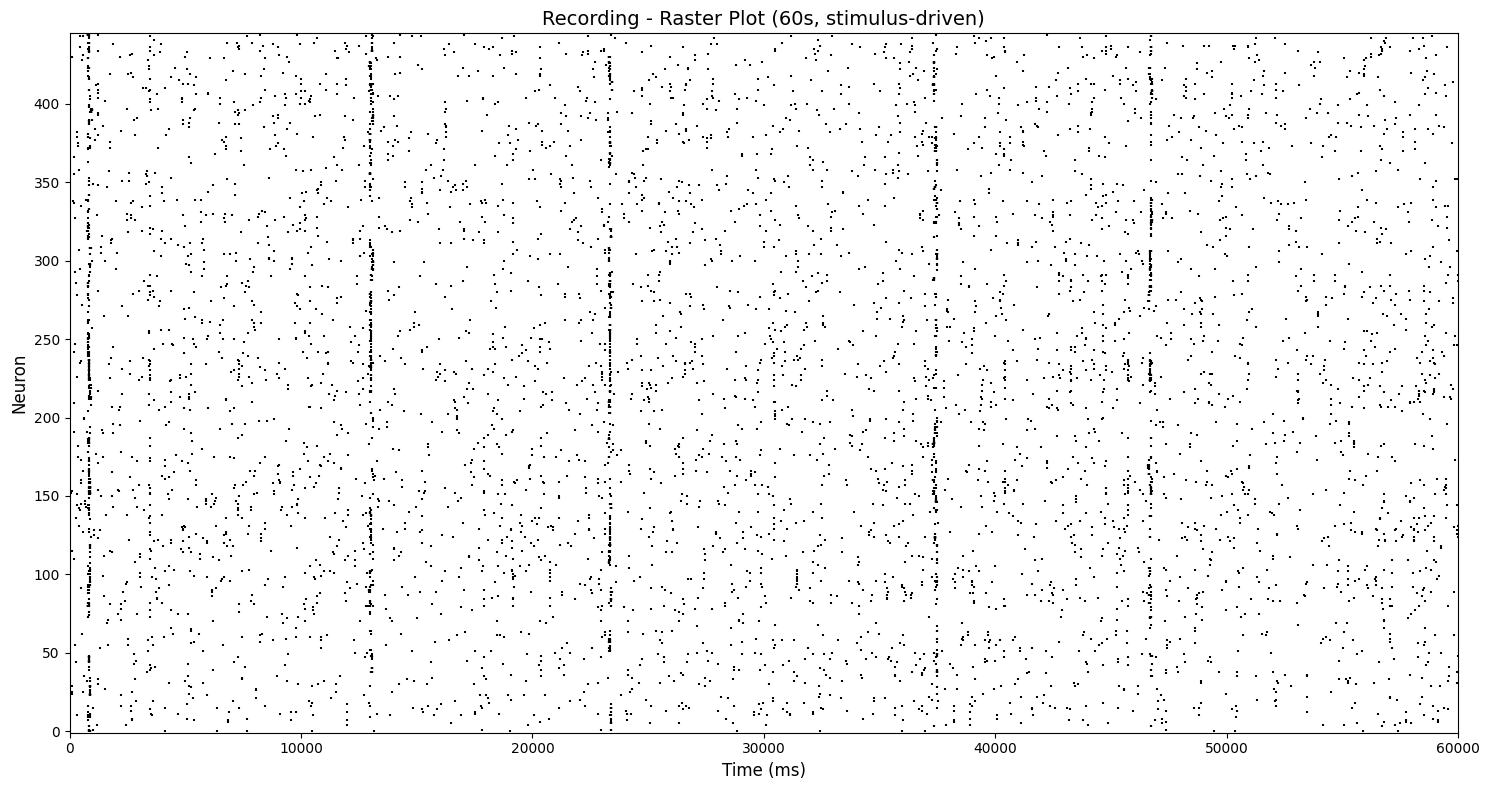

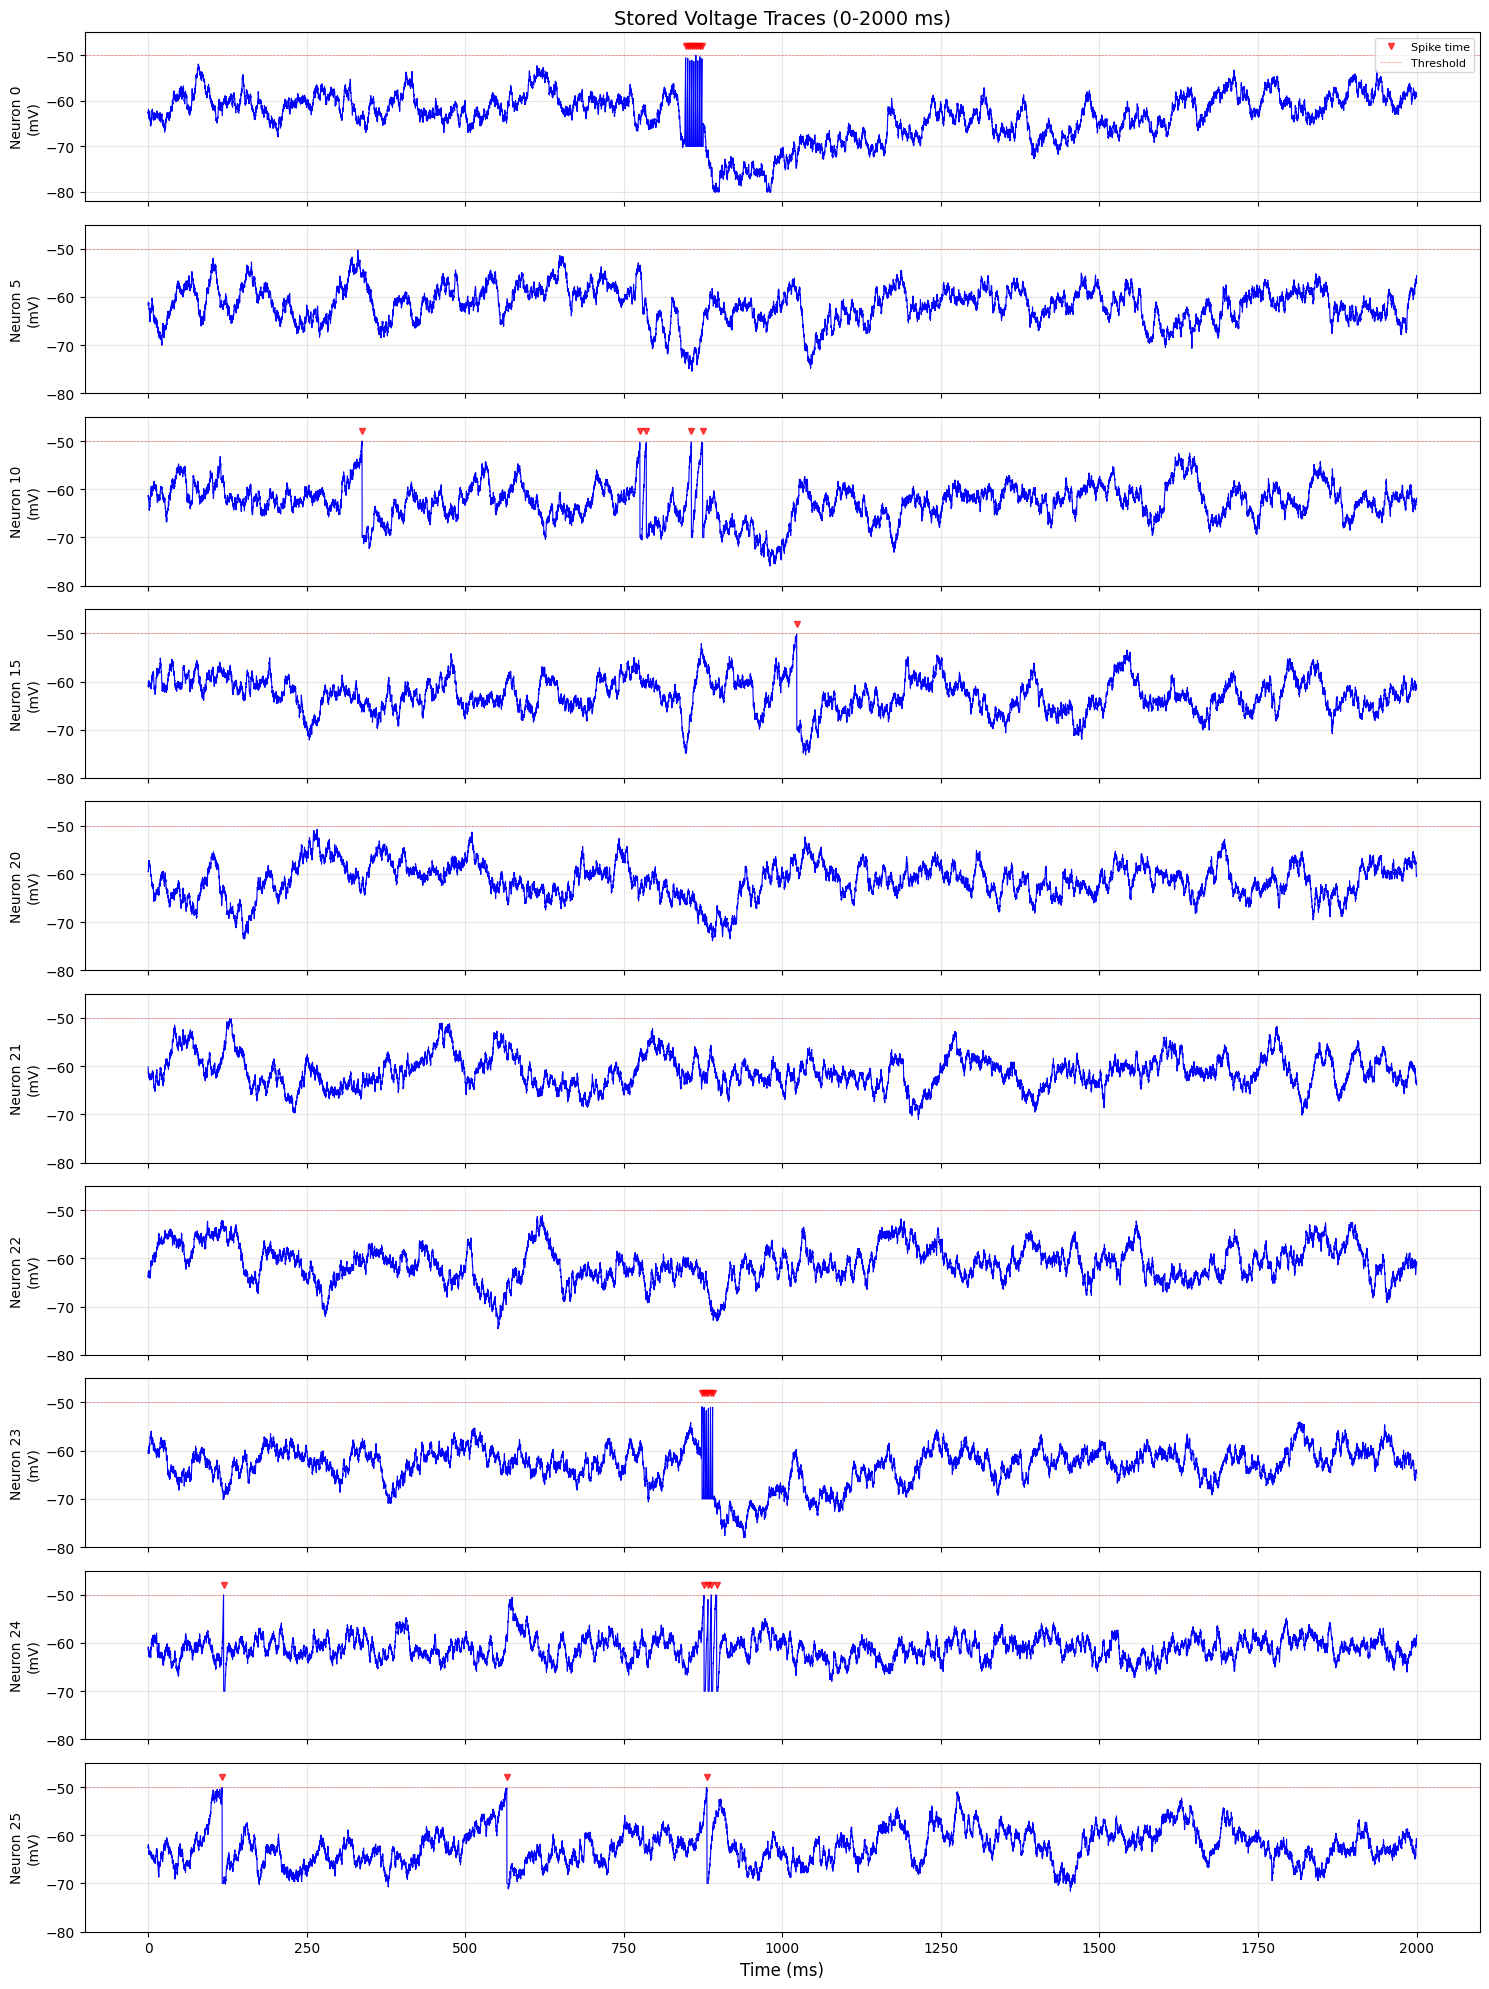

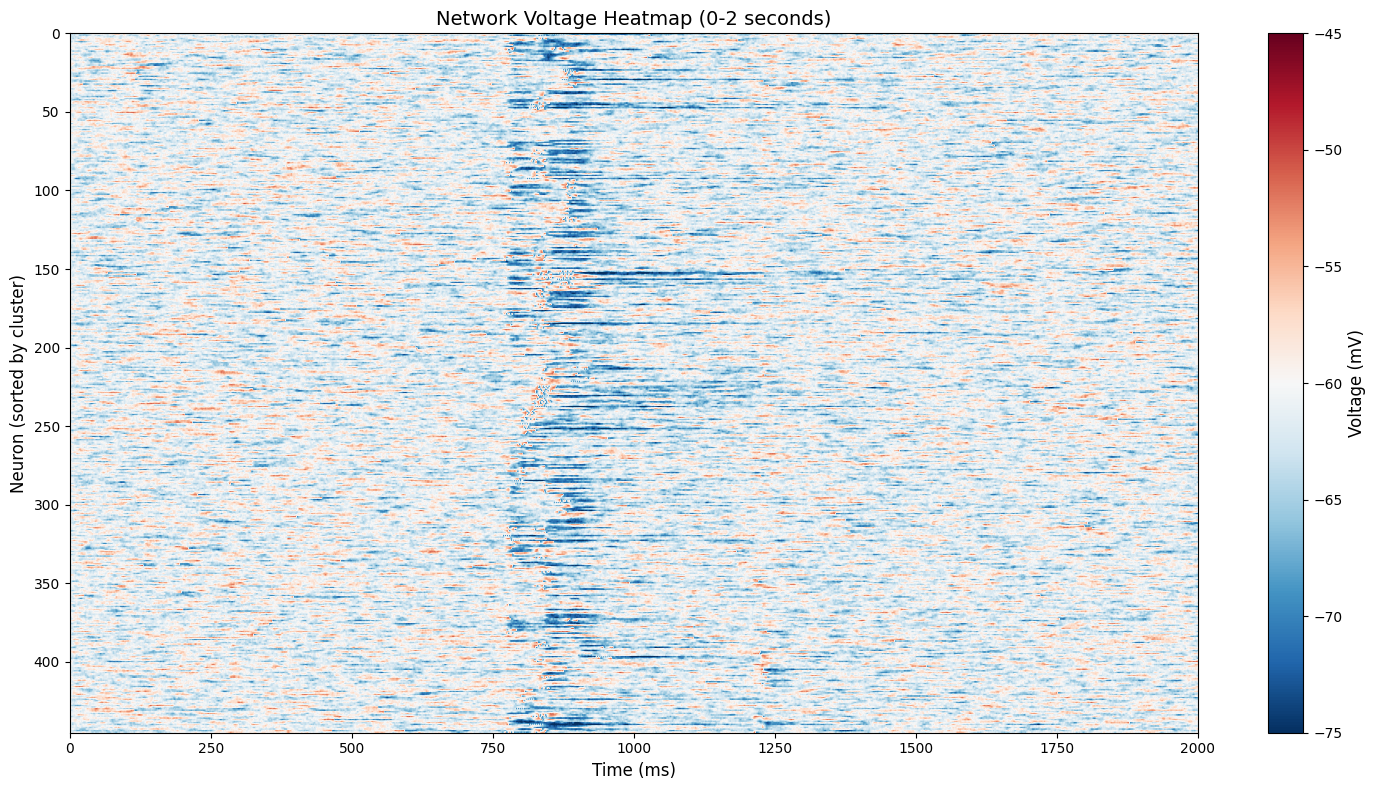

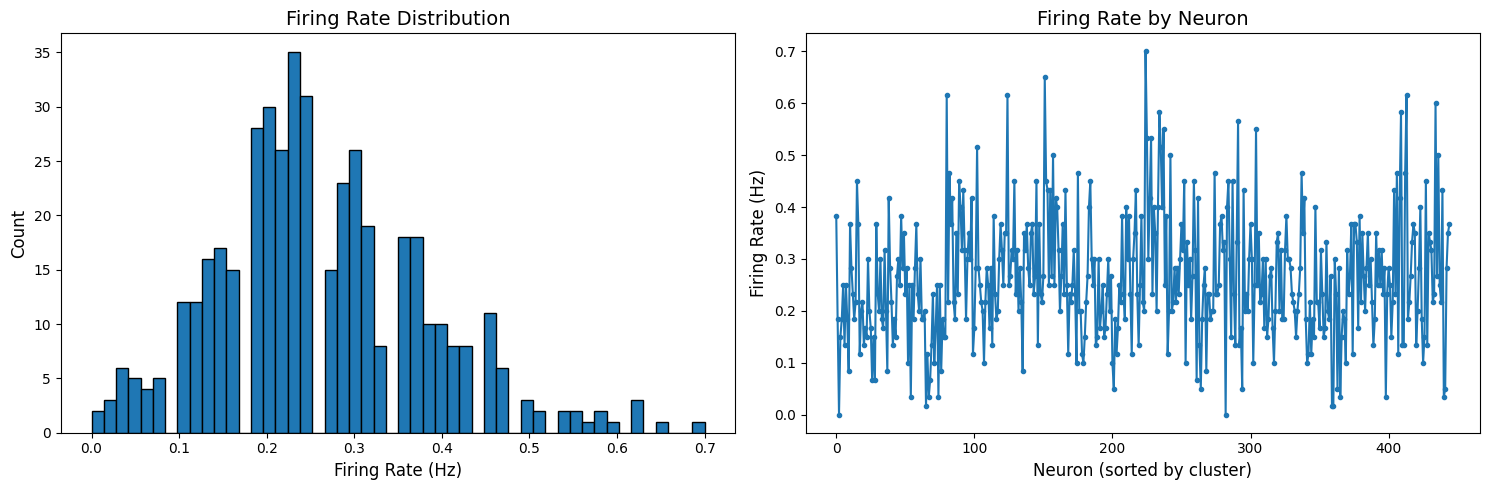

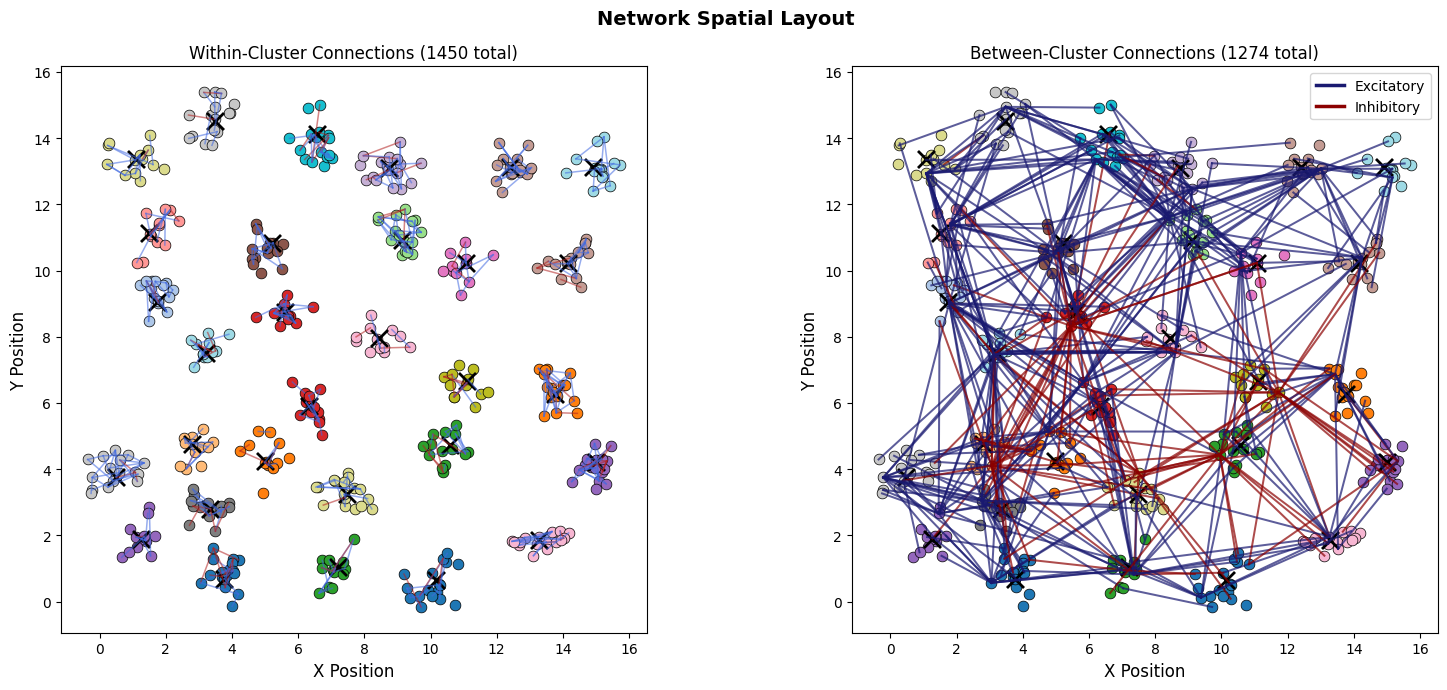

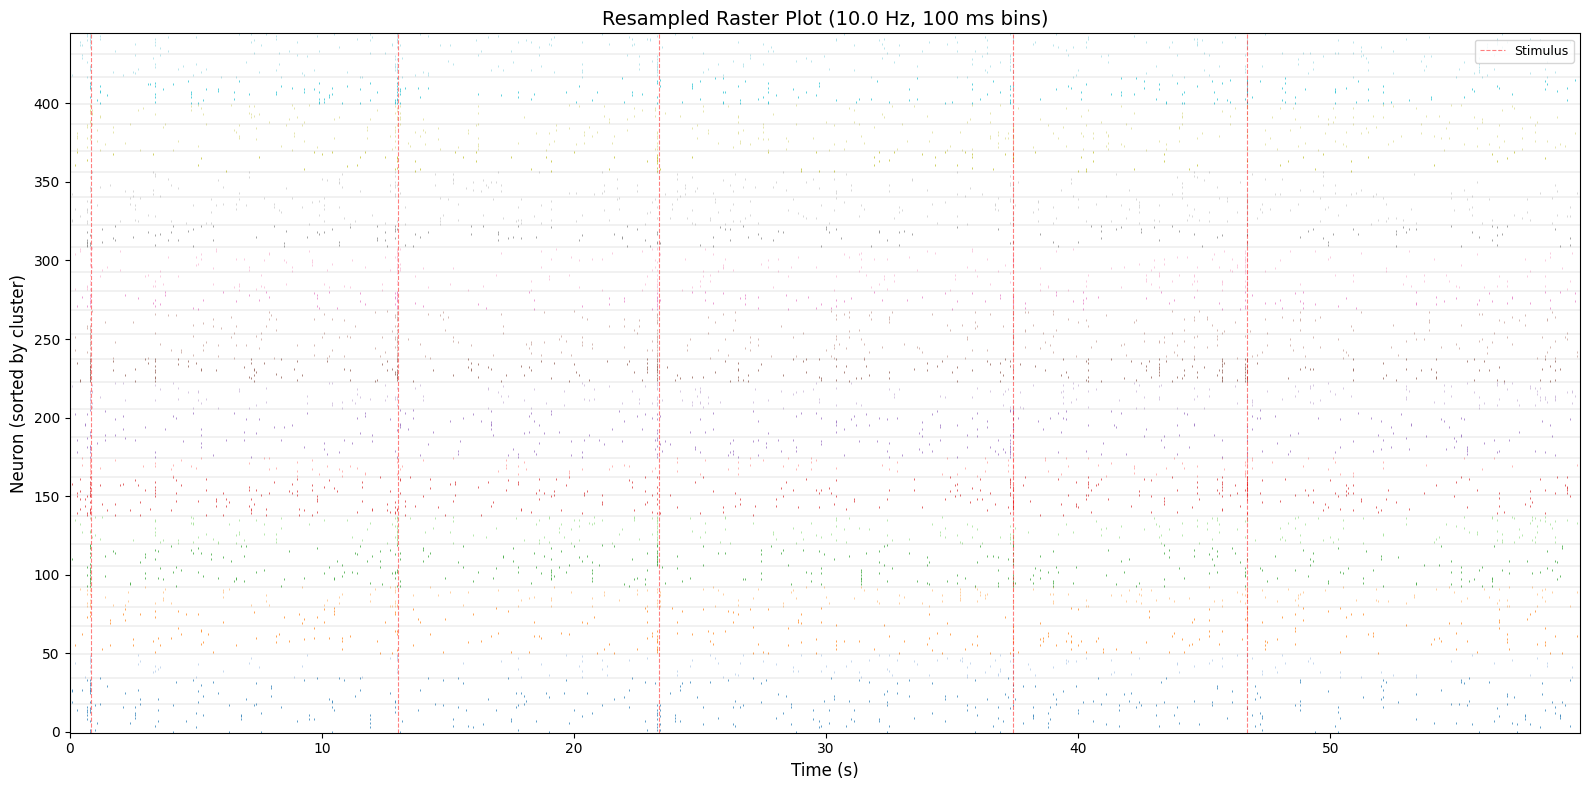

SPIKE TRAIN ANALYSIS
Expected mode: stimulus_driven
Stimulus onsets available: 5

--------------------------------------------------
1. FIRING RATE ANALYSIS
--------------------------------------------------
Mean firing rate: 0.261 +/- 0.120 Hz
Median firing rate: 0.250 Hz
Range: 0.000 - 0.700 Hz
Active neurons: 443 / 445 (99.6%)
Silent neurons: 2

--------------------------------------------------
2. INTER-SPIKE INTERVAL (ISI) ANALYSIS
--------------------------------------------------
Mean ISI: 3386.56 ms
Median ISI: 2215.00 ms
Min ISI: 2.50 ms
ISI < 2 ms: 0 (0.000%)
Mean CV of ISI: 1.01 (about 1.0 is Poisson-like)

--------------------------------------------------
3. TEMPORAL DYNAMICS
--------------------------------------------------
Population rate (100 ms bins): mean=0.261 Hz, std=0.660 Hz
Max population rate: 9.146 Hz at t=800 ms
Early activity: 0.290 Hz
Late activity: 0.183 Hz
Early/late delta: -0.106 Hz
Potential synchronized bins: 6 (threshold: 15.0% active neurons per 100 m

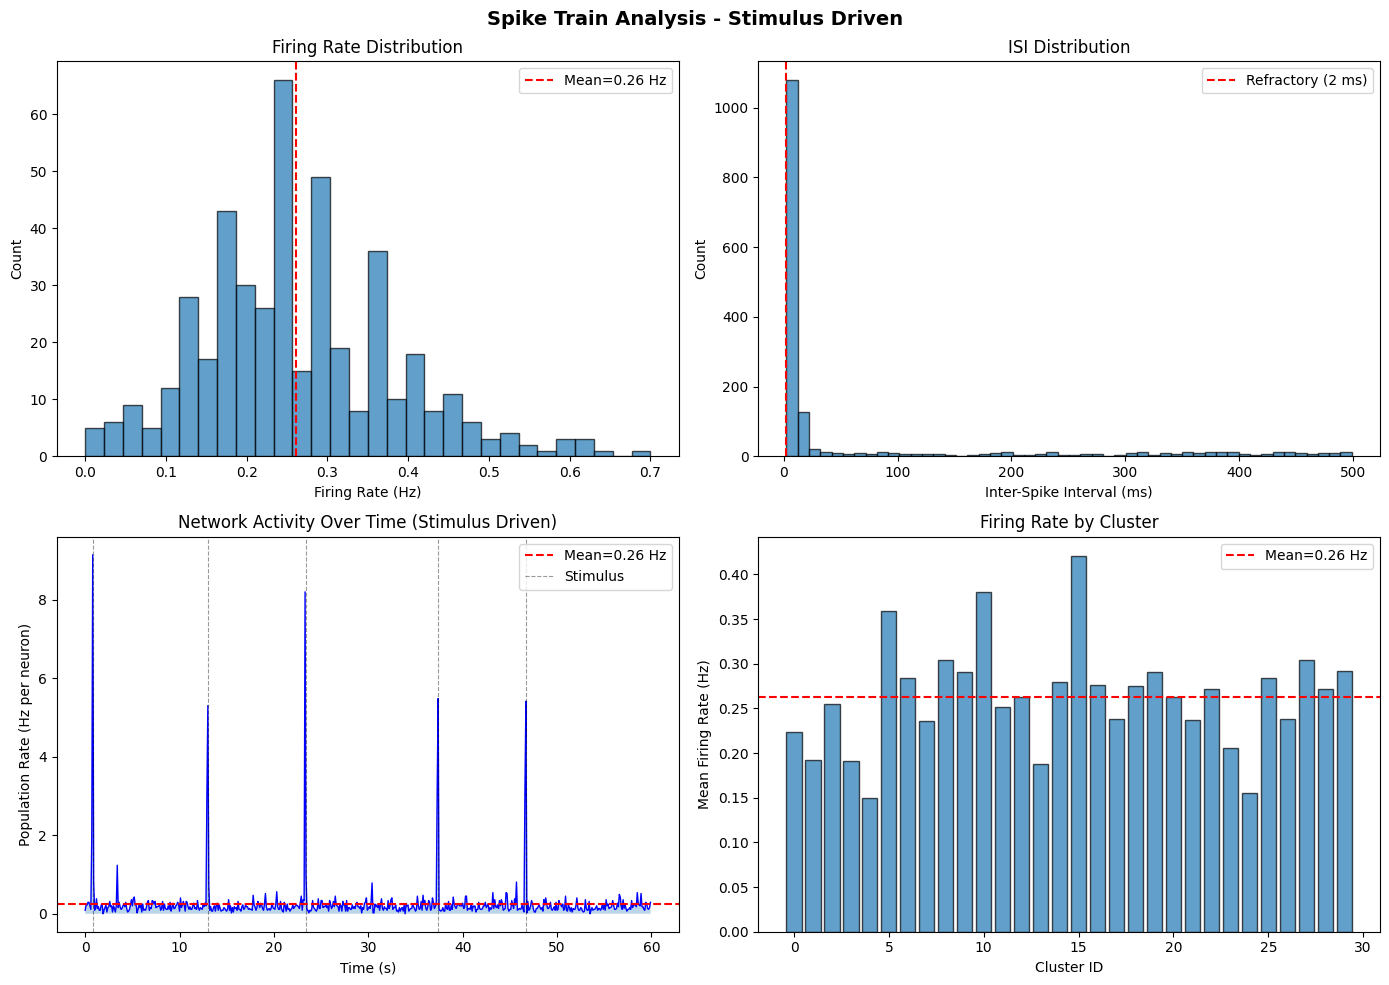

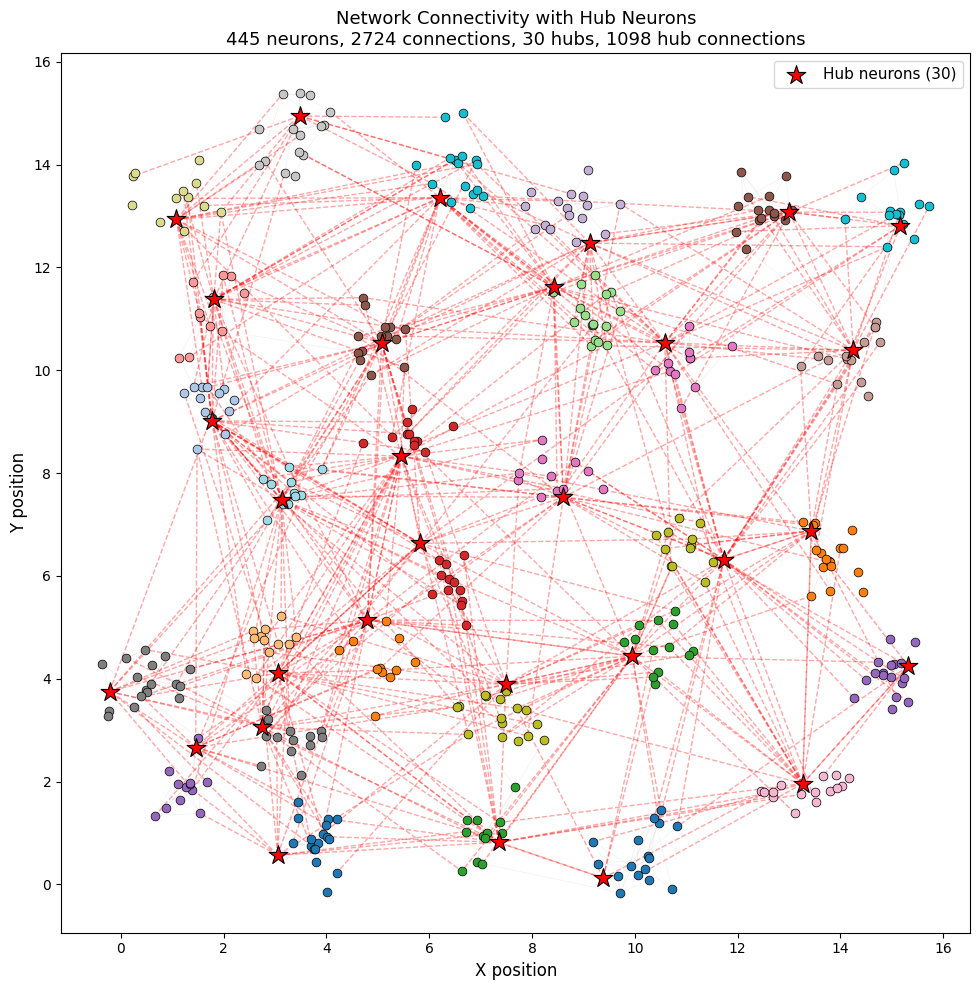

HUB NEURON VALIDATION
Total neurons: 445
Hub neurons: 30 (6.7%)
Hub fraction setting: 0.1

Hub mean total degree:     47.8 +/- 13.5
Non-hub mean total degree: 9.7 +/- 3.1
Degree ratio (hub/non-hub): 4.94x

Hub mean out-degree: 39.3 | Non-hub: 3.7
Hub mean in-degree:  8.5 | Non-hub: 5.9

Hub inter-cluster fraction:     91.9% (1083/1178)
Non-hub inter-cluster fraction: 12.4% (191/1546)

  [PASS] Degree ratio >= 2x
  [PASS] Hub between-cluster fraction > non-hub
  [PASS] Hub count > 0


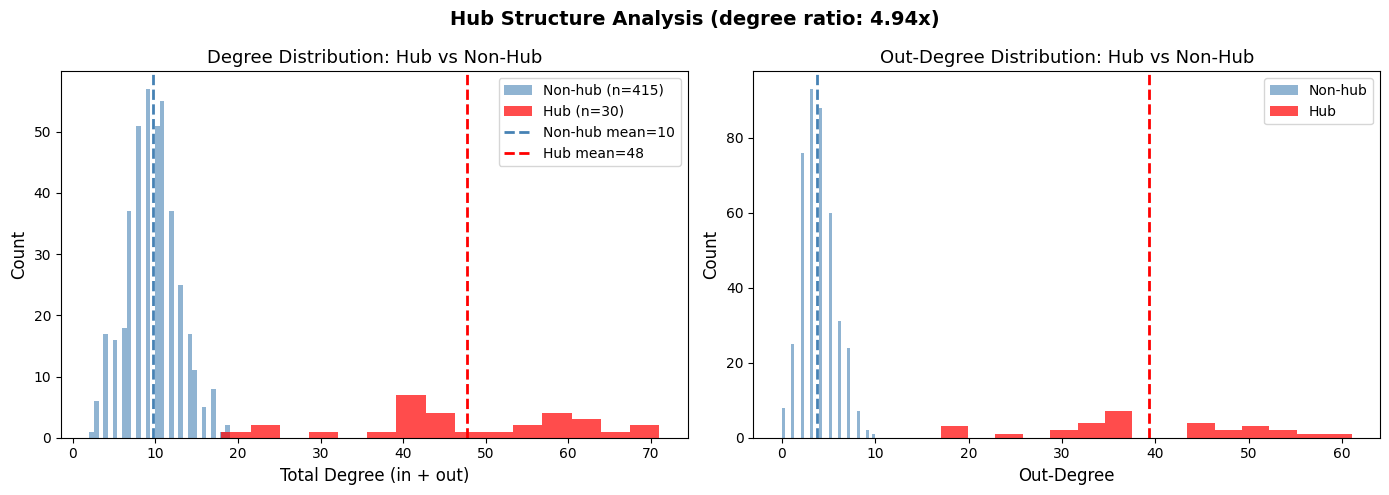

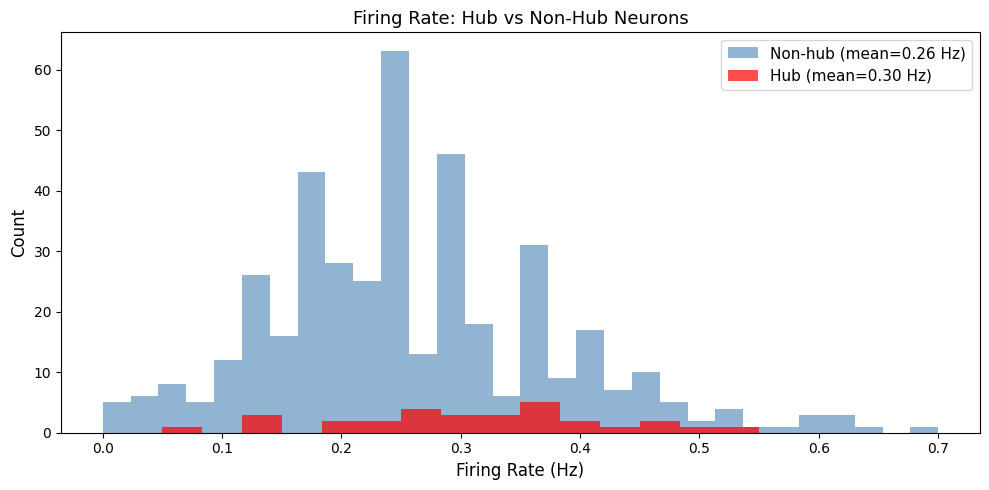

In [9]:
try:
    bundle = load_session_bundle(session_source=session_source, recording_index=recording_index)
    print(f"Loading session: {bundle['timestamp']}")
    print(f"Session folder: {bundle['session_dir']}")
    print(f"Relative session path: {bundle['relative_session_path']}")
except FileNotFoundError as exc:
    bundle = None
    print(exc)

if bundle is not None:
    activity_label = 'stimulus-driven' if bundle['stimulation_enabled'] else 'spontaneous firing'
    plot_raster(
        bundle['spike_data_dict'],
        bundle['cluster_assignments'],
        bundle['recording_duration'],
        title=f"Recording - Raster Plot ({bundle['recording_duration'] / 1000:.0f}s, {activity_label})",
    )
    plt.show()

    if bundle['voltage_data'] is not None:
        plot_voltage_traces(
            bundle['voltage_data'],
            neuron_ids=[0, 5, 10, 15, 20, 21, 22, 23, 24, 25],
            time_range=(0, 2000),
            spike_data=bundle['spike_data_dict'],
            title='Stored Voltage Traces (0-2000 ms)',
        )
        plt.show()

        plot_voltage_heatmap(
            bundle['voltage_data'],
            time_range=(0, 2000),
            cluster_assignments=bundle['cluster_assignments'],
            title='Network Voltage Heatmap (0-2 seconds)',
        )
        plt.show()

    plot_firing_rates(bundle['spike_data_dict'], bundle['cluster_assignments'], bundle['recording_duration'])
    plt.show()

    plot_network_positions(
        bundle['network_positions'],
        bundle['network_cluster_info'],
        bundle['network_connections'],
        cluster_assignments=bundle['cluster_assignments'],
        show_connections='sample',
        max_connections=500,
    )
    plt.show()

    plot_resampled_raster(
        bundle['resampled_spikes'],
        bundle['resampled_times'],
        bundle['cluster_assignments'],
        bundle['resampling_frequency'],
        burst_onset_times=bundle['burst_onset_times'],
    )
    plt.show()

    analysis_results = analyze_spike_trains(
        bundle['spike_data_dict'],
        bundle['cluster_assignments'],
        bundle['recording_duration'],
        bundle['network_connections'],
        burst_onset_times=bundle['burst_onset_times'],
    )
    plot_spike_train_analysis_summary(analysis_results)
    plt.show()

    if bundle['hub_cluster_info'] is not None:
        plot_hub_network(bundle['network_positions'], bundle['network_connections'], bundle['hub_cluster_info'])
        plt.show()

        hub_stats = validate_hub_structure(
            bundle['network_connections'],
            bundle['hub_cluster_info'],
            len(bundle['network_positions']),
        )
        if hub_stats is not None:
            plot_hub_degree_distributions(hub_stats)
            plt.show()
            rate_groups = compute_hub_firing_rate_groups(
                bundle['spike_data_dict'],
                bundle['hub_cluster_info']['hub_neuron_ids'],
                bundle['recording_duration'],
            )
            plot_hub_firing_rate_histogram(rate_groups)
            plt.show()